<a href="https://colab.research.google.com/github/anhnhat25dev/TH_DEEPLEARNING/blob/main/Buoi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CÀI ĐẶT MÔ HÌNH AUTOENCODER

In [ ]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


In [ ]:
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)
# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0103 - loss: 0.2756 - val_accuracy: 0.0108 - val_loss: 0.1883
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0115 - loss: 0.1693 - val_accuracy: 0.0113 - val_loss: 0.1527
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0109 - loss: 0.1443 - val_accuracy: 0.0097 - val_loss: 0.1341
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0103 - loss: 0.1289 - val_accuracy: 0.0081 - val_loss: 0.1215
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0103 - loss: 0.1183 - val_accuracy: 0.0072 - val_loss: 0.1126
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0104 - loss: 0.1107 - val_accuracy: 0.0094 - val_loss: 0.1065
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0105 - loss: 0.1053 - val_accuracy: 0.0100 - val_loss: 0.1019
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0108 - loss: 0.1015 - val_accuracy: 0.

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step


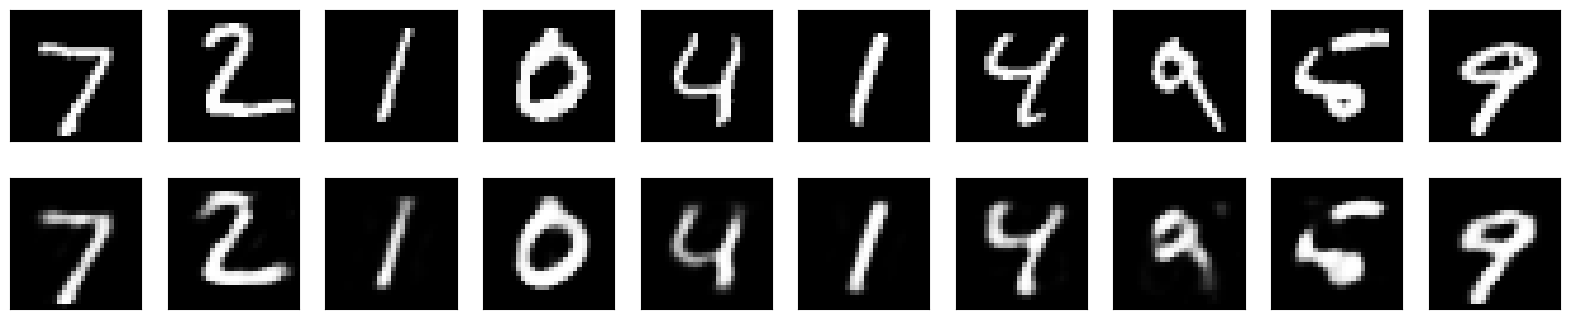

In [ ]:
# Use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n = 10  # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [ ]:
from keras import regularizers

In [ ]:
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)
# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                epochs=100,
                batch_size=256, verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0144 - loss: 0.6552 - val_accuracy: 0.0143 - val_loss: 0.6155
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0151 - loss: 0.5832 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0147 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0152 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0149 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0150 - loss: 0.3739 - val_accu

In [ ]:
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

#method 2: increasing multi-layers

# This is our input image
input_img = keras.Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
# "decoded" is the lossy reconstruction of the input

decoded = layers.Dense(784, activation='sigmoid')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded)

# This model maps an input to its encoded representation
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(32,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))


=== ĐANG HUẤN LUYỆN VỚI EPOCHS = 50 ===
-> Hoàn thành! Final Train Loss: 0.0928 | Final Val Loss: 0.0916

=== ĐANG HUẤN LUYỆN VỚI EPOCHS = 100 ===
-> Hoàn thành! Final Train Loss: 0.0924 | Final Val Loss: 0.0914

=== ĐANG HUẤN LUYỆN VỚI EPOCHS = 200 ===
-> Hoàn thành! Final Train Loss: 0.0919 | Final Val Loss: 0.0909


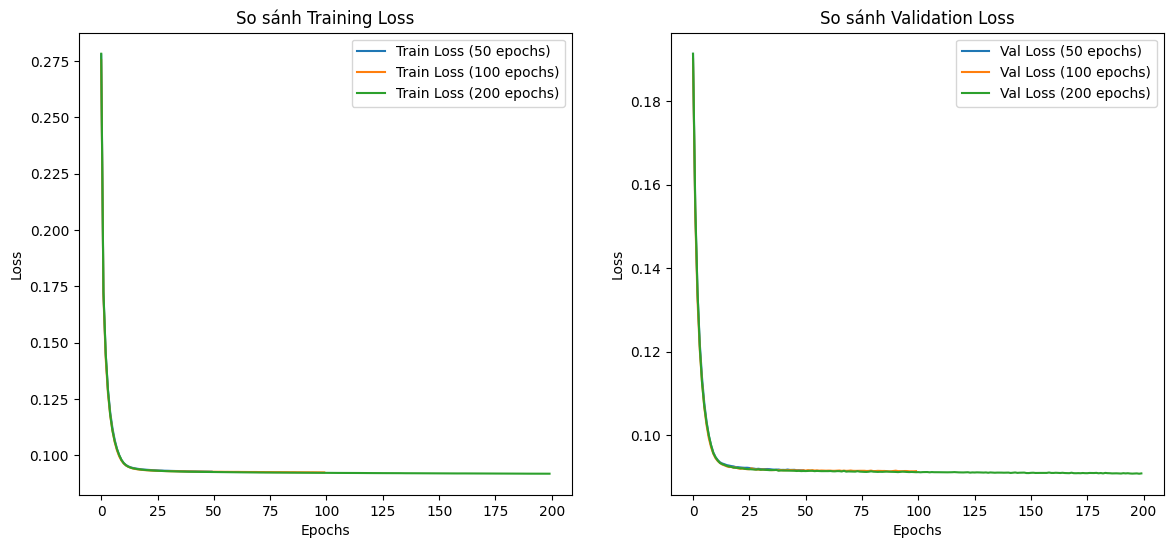

In [ ]:
import matplotlib.pyplot as plt

# Danh sách các mức epochs cần thử nghiệm
epoch_list = [50, 100, 200]
histories = {}

# Vòng lặp huấn luyện tự động
for ep in epoch_list:
    print(f"\n=== ĐANG HUẤN LUYỆN VỚI EPOCHS = {ep} ===")

    # Định nghĩa lại mô hình trống để xóa trọng số cũ trước khi train mức mới
    # (Giả sử bạn đang dùng kiến trúc Simple Autoencoder ở mục 2.3)
    input_img = keras.Input(shape=(784,))
    encoded = layers.Dense(32, activation='relu')(input_img)
    decoded = layers.Dense(784, activation='sigmoid')(encoded)
    autoencoder_test = keras.Model(input_img, decoded)

    autoencoder_test.compile(optimizer='adam', loss='binary_crossentropy')

    # Huấn luyện và lưu kết quả vào dictionary
    history = autoencoder_test.fit(x_train, x_train,
                                   epochs=ep,
                                   batch_size=256,
                                   shuffle=True,
                                   validation_data=(x_test, x_test),
                                   verbose=0) # verbose=0 để ẩn bớt log dòng chạy dài

    histories[ep] = history
    print(f"-> Hoàn thành! Final Train Loss: {history.history['loss'][-1]:.4f} | Final Val Loss: {history.history['val_loss'][-1]:.4f}")

# --- VẼ ĐỒ THỊ SO SÁNH LOSS ---
plt.figure(figsize=(14, 6))

# Đồ thị Train Loss
plt.subplot(1, 2, 1)
for ep in epoch_list:
    plt.plot(histories[ep].history['loss'], label=f'Train Loss ({ep} epochs)')
plt.title('So sánh Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Đồ thị Validation Loss
plt.subplot(1, 2, 2)
for ep in epoch_list:
    plt.plot(histories[ep].history['val_loss'], label=f'Val Loss ({ep} epochs)')
plt.title('So sánh Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from keras.models import Model
import matplotlib.pyplot as plt

In [ ]:
# Tải bộ dữ liệu CIFAR10 có sẵn trong Keras
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

# Chuẩn hóa giá trị pixel ảnh về khoảng [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print("Kích thước tập Train:", x_train.shape) # (50000, 32, 32, 3)
print("Kích thước tập Test:", x_test.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Kích thước tập Train: (50000, 32, 32, 3)
Kích thước tập Test: (10000, 32, 32, 3)


In [ ]:
# --- 1. ĐỊNH NGHĨA ENCODER (Bộ mã hóa) ---
input_img = layers.Input(shape=(32, 32, 3))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Giảm về (16, 16, 32)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Giảm về (8, 8, 16) - Đây là không gian nén (Bottleneck)

# --- 2. ĐỊNH NGHĨA DECODER (Bộ giải mã) ---
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(encoded) # Tăng lên (16, 16, 16)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x) # Tăng lên (32, 32, 32)
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x) # Trả về (32, 32, 3)

# --- 3. ĐỊNH NGHĨA MÔ HÌNH TỔNG AUTOENCODER ---
autoencoder = Model(input_img, decoded)

# Tách riêng mô hình Encoder để lấy không gian nén nếu cần
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='mean_squared_error') # Dùng MSE loss cho bài toán tái tạo ảnh màu
autoencoder.summary()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Bạn có thể điều chỉnh số lượng epochs lên 50, 100 hoặc 200 theo yêu cầu bài thực hành trước
history = autoencoder.fit(x_train, x_train,
                          epochs=30,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(x_test, x_test),
                          verbose=1)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 197ms/step - loss: 0.0172 - val_loss: 0.0082
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 194ms/step - loss: 0.0073 - val_loss: 0.0066
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 192ms/step - loss: 0.0063 - val_loss: 0.0058
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 202ms/step - loss: 0.0045 - val_loss: 0.0044
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 209ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 9/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 10/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 207ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 11/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 247ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 12/30
391/391

In [ ]:
# Tiến hành nén và giải nén các bức ảnh trong tập Test
decoded_imgs = autoencoder.predict(x_test)
print("Đã dự báo và tái tạo ảnh xong!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Đã dự báo và tái tạo ảnh xong!


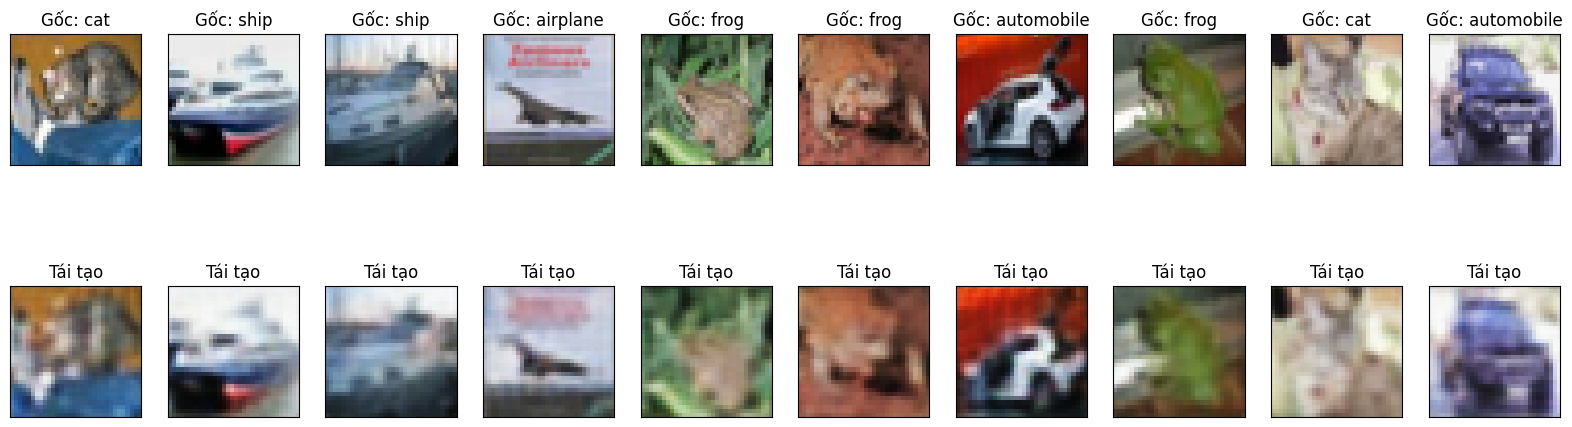

In [ ]:
# Danh sách nhãn bằng tiếng Anh theo mô tả đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
(_, y_train_label), (_, y_test_label) = keras.datasets.cifar10.load_data()

n = 10  # Số lượng ảnh hiển thị
plt.figure(figsize=(20, 6))

for i in range(n):
    # 1. Hiển thị ảnh gốc (Original) ở hàng trên
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    label_idx = y_test_label[i][0]
    plt.title(f"Gốc: {class_names[label_idx]}")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 2. Hiển thị ảnh sau khi phục hồi (Reconstructed) ở hàng dưới
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Tái tạo")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()